In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    compute_rate_trend_categories,
    compute_rate_trend_pmf,
    create_flusight_submission,
    RATE_TREND_CATEGORIES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons,
    get_flusight_categorical_horizons,
)
from epymodelingsuite.utils.location import convert_location_name_format


## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202619"
REFERENCE_DATE = "2026-05-16"
WINDOW = "202550-202618"

Choose augmentation and baseline:

In [3]:
AUGMENTED = True
BASELINE = True
BASELINE_k = 5

These configs are unlikely to need changing:

In [4]:
INCLUDE_SINGLE_STRAIN = True
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "hosp_aug" if AUGMENTED else "hosp"
TARGET_LONG = "flu_hosp_25"
SUFFIX = "_augmented" if AUGMENTED else ""
LOCAL_PARENT_DIR = "../experiments/multistrain"

Derived config values:

In [5]:
VALUE_COL = "target_total" if BASELINE else "target_sum"
MULTISTRAIN_EXPERIMENT = f"multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}"
WORKING_DIR = f"{LOCAL_PARENT_DIR}/{SUBMISSION_WEEK}-{TARGET}/{MULTISTRAIN_EXPERIMENT}"
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-06-13 00:00:00')

## Data

In [6]:
if INCLUDE_SINGLE_STRAIN:
    # Load single-strain submission file
    single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}"
    single_fname = f"output_hub_formatted.csv.gz"
    df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
    df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202619/hosp_aug_smc_wrmse_202550-202618/20260513-151910-ed29732b/outputs/20260513-173039/output_hub_formatted.csv.gz to file:///tmp/tmparbgqrze/output_hub_formatted.csv.gz
  


Downloaded: output_hub_formatted.csv.gz


.


In [7]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_prelim{SUFFIX}.csv")
fit_surv_data['abbreviation'] = fit_surv_data['location_iso'].apply(lambda key: key.split("-")[-1])
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['target_end_date'])

# Compute quantiles
random_combined = pd.read_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz")

traj_loc_fmt = (
    "location_name_epydemix"
    if random_combined.location.str.contains("__").any()
    else "location_name_epydemix_deprecated"
)

if BASELINE:
    baselines_avg = pd.read_csv("epymodelingsuite/data/baselines_hosp_2025.csv")
    random_combined = random_combined.merge(baselines_avg,
                                            left_on = "location",
                                            right_on=traj_loc_fmt)
    p_values = BASELINE_k / (BASELINE_k + random_combined['baseline'])
    random_combined['baseline_sample'] = np.random.negative_binomial(BASELINE_k, p_values)
    random_combined['target_total'] = random_combined['target_sum'] + random_combined['baseline_sample']
    random_combined.drop(
        columns=["location_name","location_name_epydemix","location_name_epydemix_deprecated",
                 "location_abbreviation","location_code","ISO","baseline"],
        inplace=True
    )
    random_combined.to_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz", index=False)

random_quantiles = compute_quantiles(random_combined, value_col=VALUE_COL)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 52 locations


In [34]:
random_combined

,sample_id,sim_id_h1,sim_id_h3,sim_id_b,location,date,target_h1,target_h3,target_b,target_sum,...,location_abbreviation_y,location_code_y,ISO_y,location_name,baseline,location_name_epydemix,location_name_epydemix_deprecated,location_abbreviation,location_code,ISO
0,264,771,371,0,United_States,2025-09-20,NaN,NaN,NaN,0.0,...,US,US,US,United States,889.083333,United_States,United_States,US,US,US
1,264,771,371,0,United_States,2025-09-27,NaN,NaN,NaN,0.0,...,US,US,US,United States,889.083333,United_States,United_States,US,US,US
2,264,771,371,0,United_States,2025-10-04,NaN,NaN,NaN,0.0,...,US,US,US,United States,889.083333,United_States,United_States,US,US,US
3,264,771,371,0,United_States,2025-10-11,NaN,NaN,NaN,0.0,...,US,US,US,United States,889.083333,United_States,United_States,US,US,US
4,264,771,371,0,United_States,2025-10-18,NaN,NaN,NaN,0.0,...,US,US,US,United States,889.083333,United_States,United_States,US,US,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079995,529,474,482,999,United_States__Wyoming,2026-05-23,0.0,0.0,0.0,0.0,...,WY,56,US-WY,Wyoming,0.750000,United_States__Wyoming,United_States_Wyoming,WY,56,US-WY
2079996,529,474,482,999,United_States__Wyoming,2026-05-30,0.0,0.0,1.0,1.0,...,WY,56,US-WY,Wyoming,0.750000,United_States__Wyoming,United_States_Wyoming,WY,56,US-WY
2079997,529,474,482,999,United_States__Wyoming,2026-06-06,0.0,0.0,1.0,1.0,...,WY,56,US-WY,Wyoming,0.750000,United_States__Wyoming,United_States_Wyoming,WY,56,US-WY
2079998,529,474,482,999,United_States__Wyoming,2026-06-13,0.0,0.0,0.0,0.0,...,WY,56,US-WY,Wyoming,0.750000,United_States__Wyoming,United_States_Wyoming,WY,56,US-WY


In [36]:
# random_combined = random_combined.merge(baselines_avg,
#                                         left_on = "location",
#                                         right_on=traj_loc_fmt)
p_values = BASELINE_k / (BASELINE_k + random_combined['baseline'])
baseline_sample = np.random.negative_binomial(BASELINE_k, p_values)
baseline_sample

array([1144,  539, 1133, ...,    0,    0,    1], shape=(2080000,))

In [53]:
baselines_ed_avg = pd.read_csv("epymodelingsuite/data/baselines_ed_2025.csv")

0.000508 2.5399999999999997e-07


(array([476., 232., 146.,  75.,  31.,  23.,   8.,   3.,   5.,   1.]),
 array([1.61525762e-06, 3.35806578e-04, 6.69997898e-04, 1.00418922e-03,
        1.33838054e-03, 1.67257186e-03, 2.00676318e-03, 2.34095450e-03,
        2.67514582e-03, 3.00933714e-03, 3.34352846e-03]),
 <BarContainer object of 10 artists>)

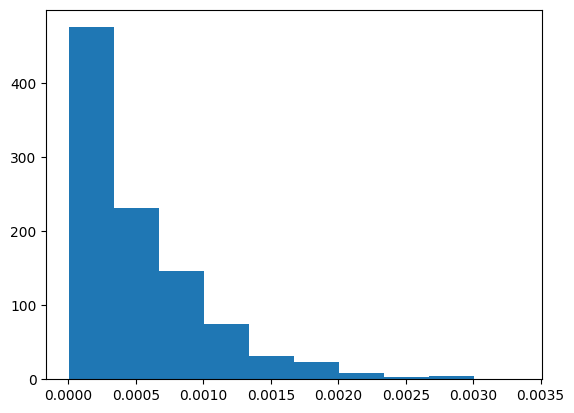

In [89]:
from scipy.stats import beta

def beta_from_mean_var(mu, var):
    if var <= 0 or var >= mu * (1 - mu):
        raise ValueError("Need 0 < var < mu*(1-mu)")
    nu = mu * (1 - mu) / var - 1
    return mu * nu, (1 - mu) * nu


baseline_mean = 0.000508
baseline_var = baseline_mean / 10000 * 5
a, b = beta_from_mean_var(baseline_mean, baseline_var)
dist = beta(a, b)
print(dist.mean(), dist.var())
samples = dist.rvs(1000)
plt.hist(samples)

United_States
0.0013249999999999998


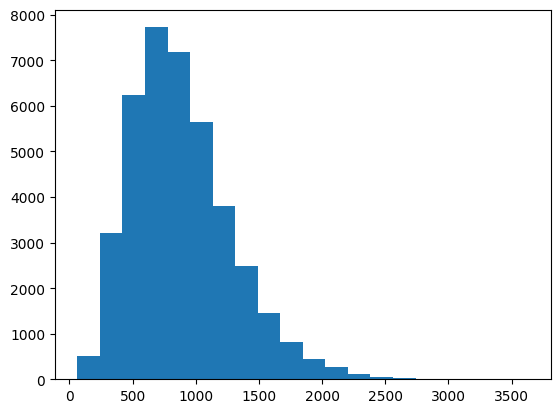

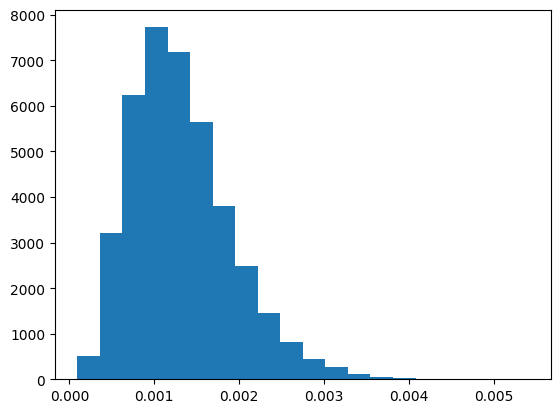

United_States__Alabama
0.0020916666666666


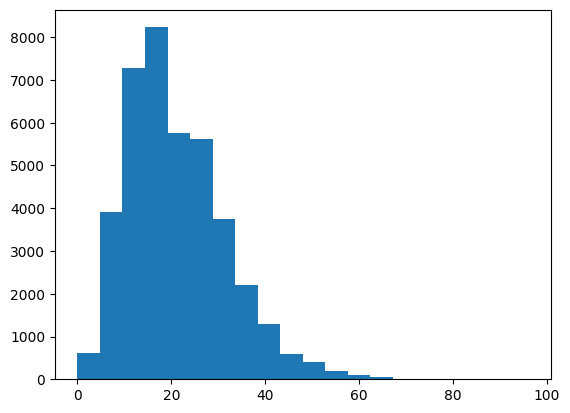

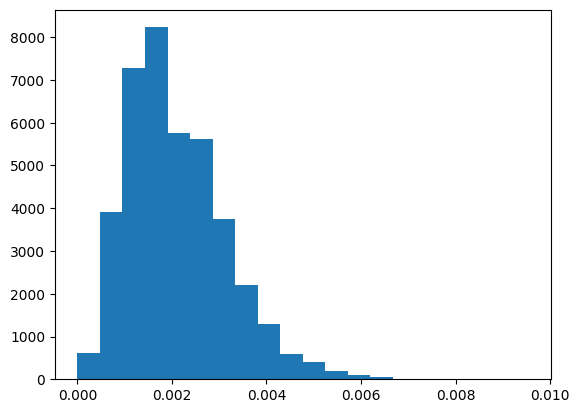

United_States__Alaska
0.0023083333333332994


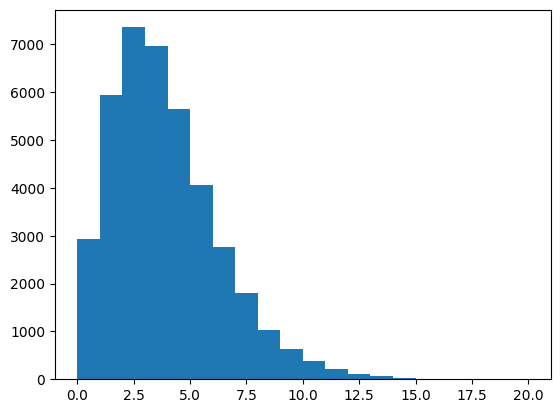

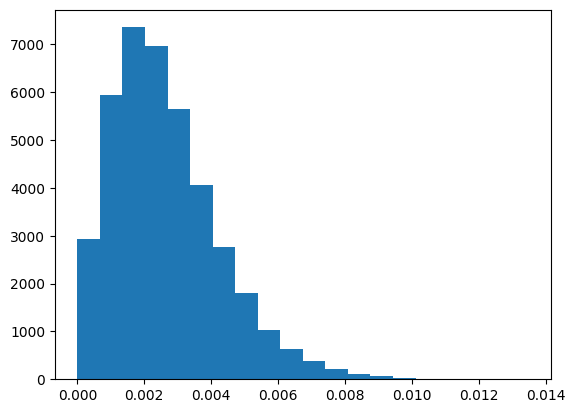

United_States__Arizona
0.000725


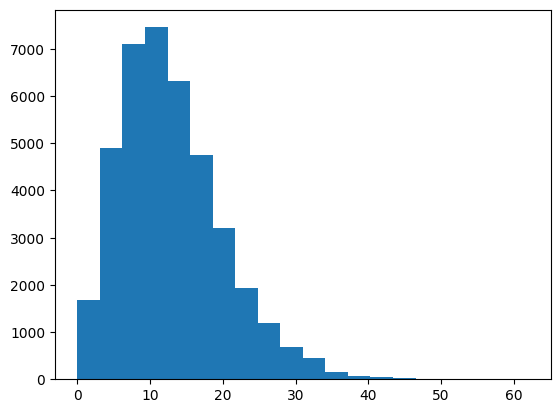

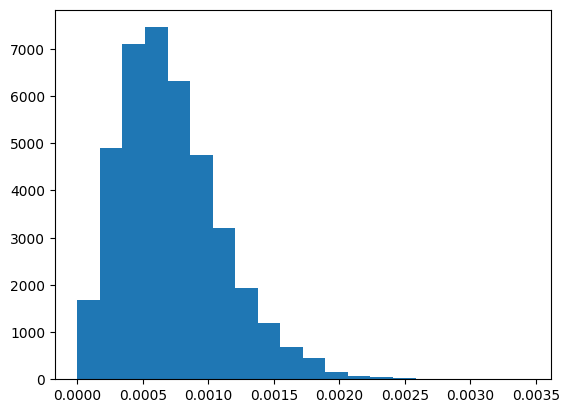

United_States__Arkansas
0.0005833333333333


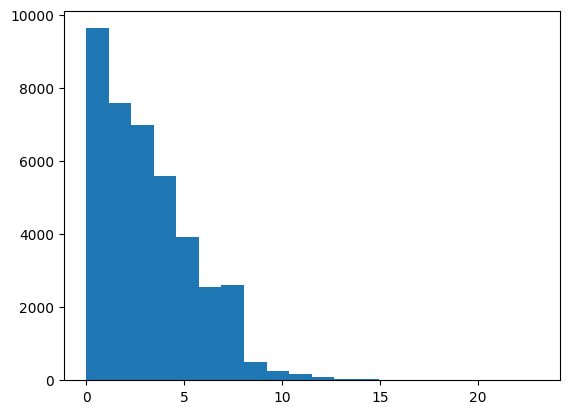

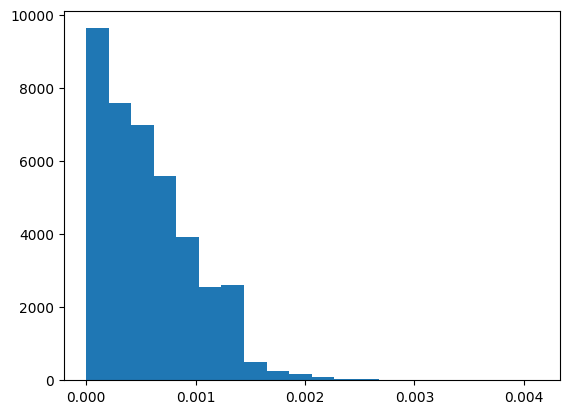

United_States__California
0.0011666666666666


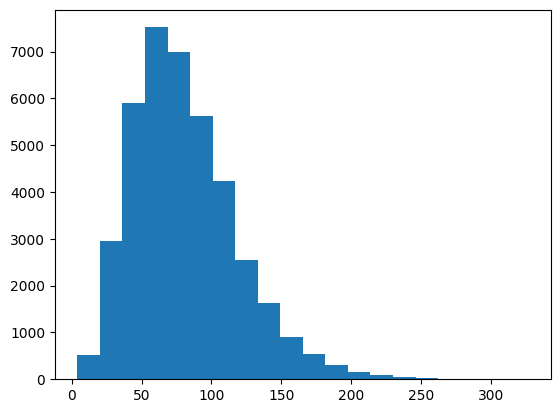

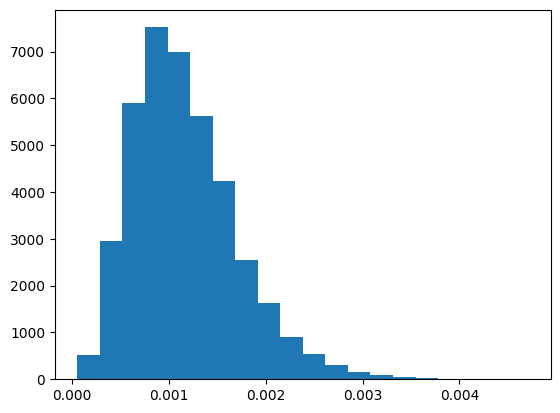

United_States__Colorado
0.0005749999999999999


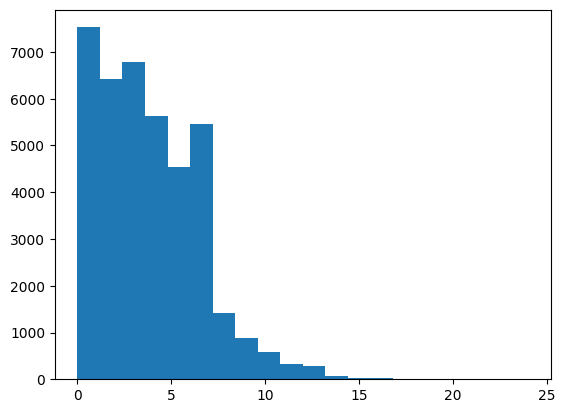

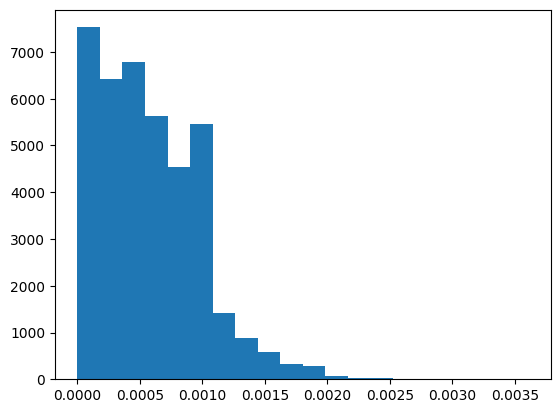

United_States__Connecticut
0.0005083333333333001


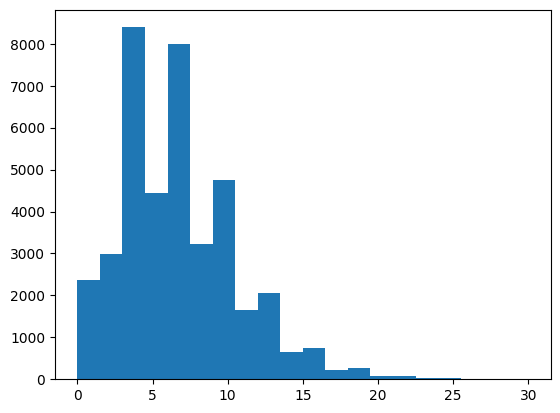

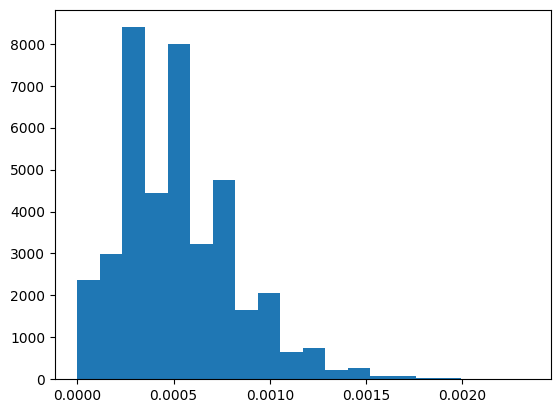

United_States__Delaware
0.0003916666666666


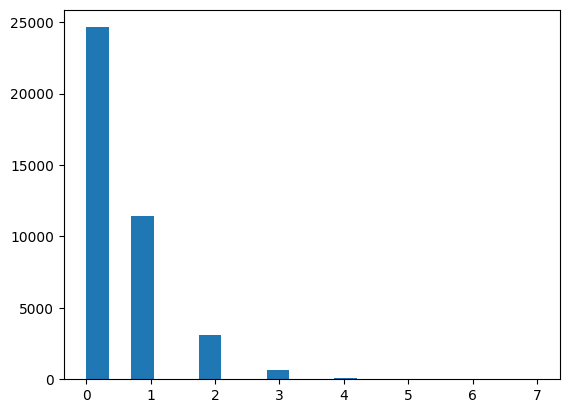

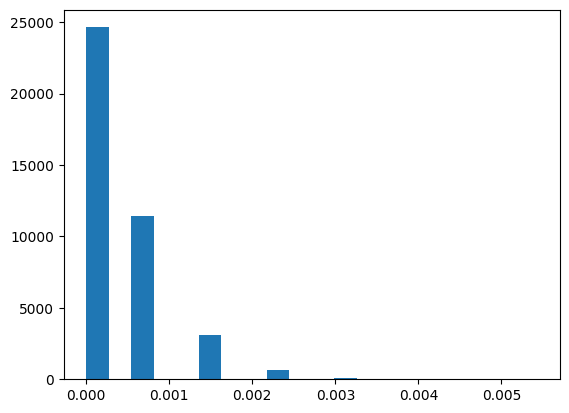

United_States__District_of_Columbia
0.0007916666666666


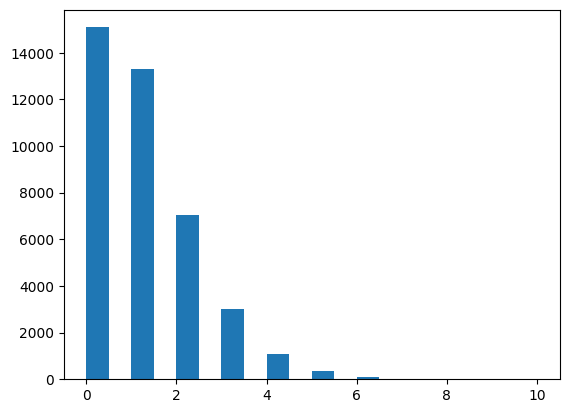

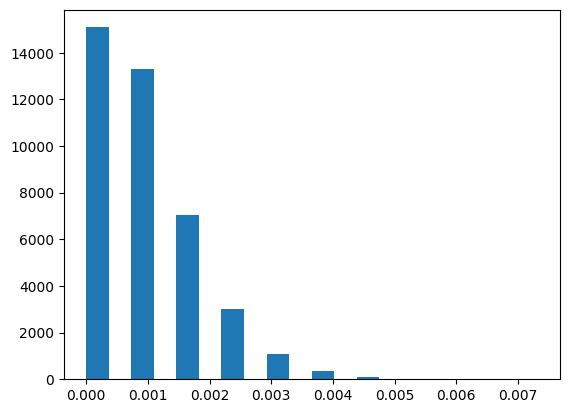

United_States__Florida
0.0030166666666666


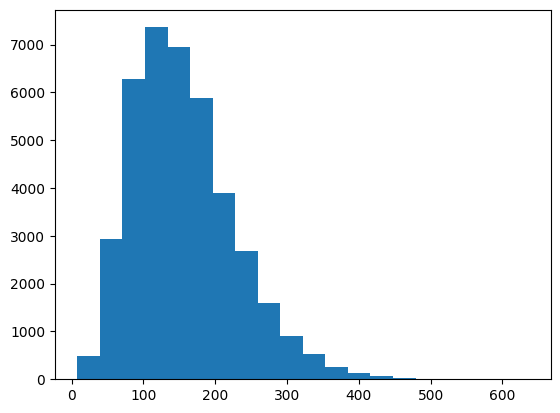

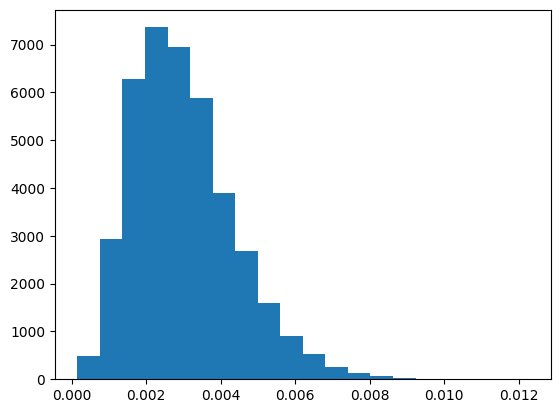

United_States__Georgia
0.0009


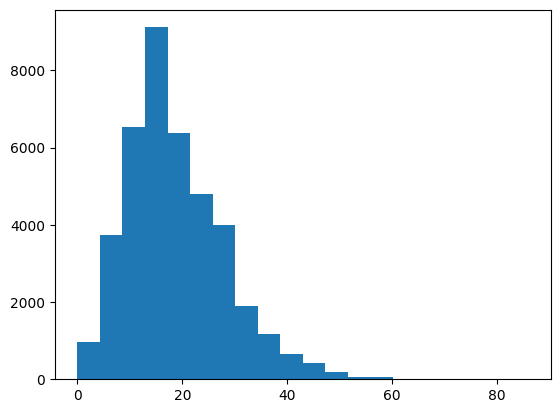

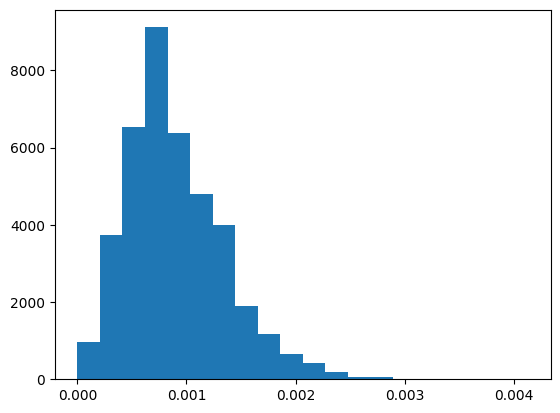

United_States__Hawaii
0.003525


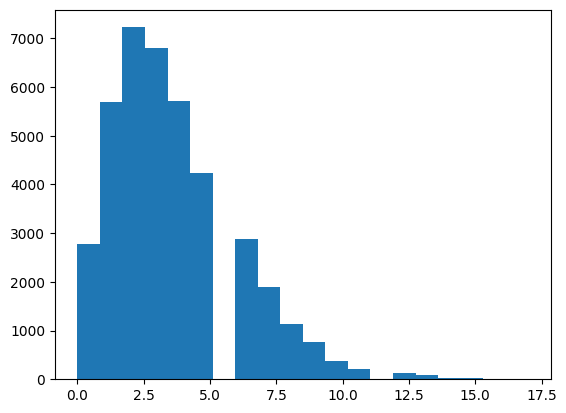

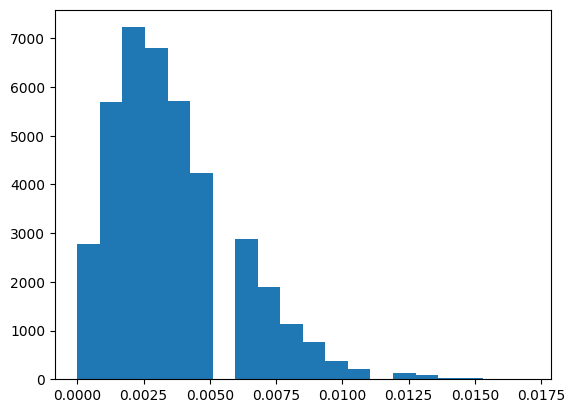

United_States__Idaho
0.0010166666666666


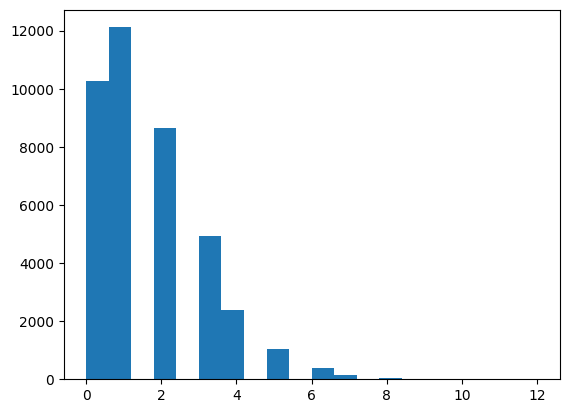

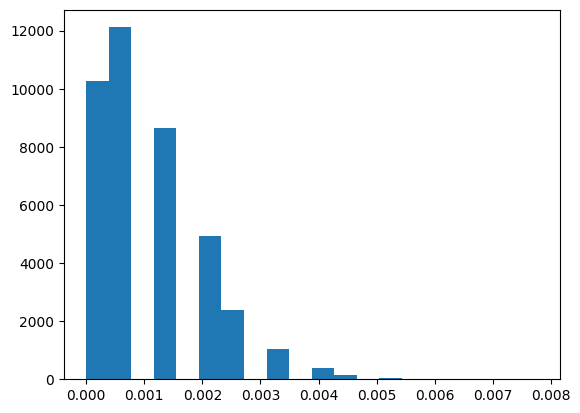

United_States__Illinois
0.0005083333333333


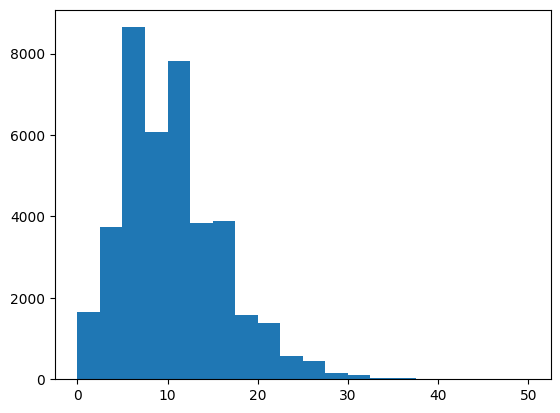

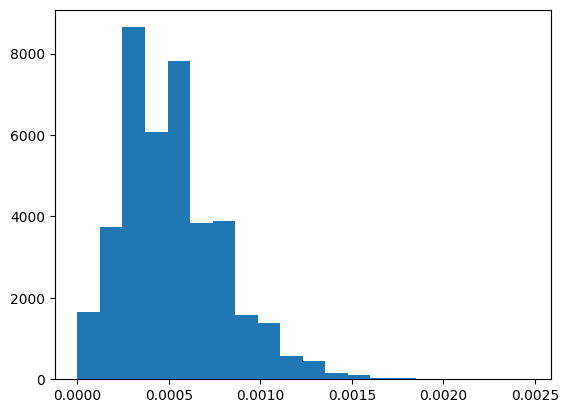

United_States__Indiana
0.0004333333333332999


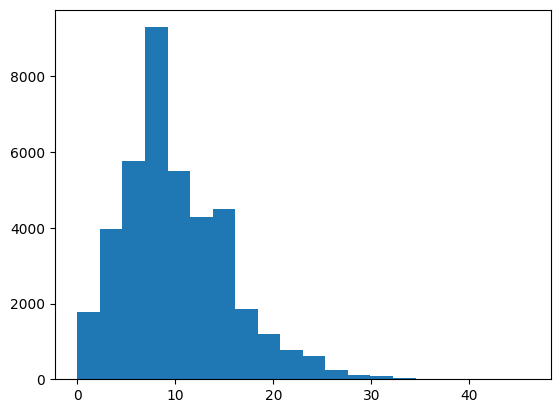

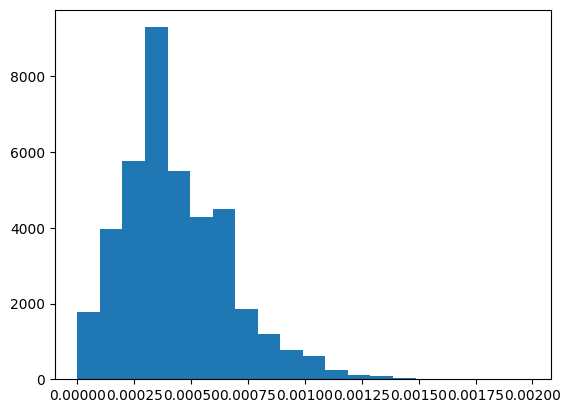

United_States__Iowa
0.0004083333333333


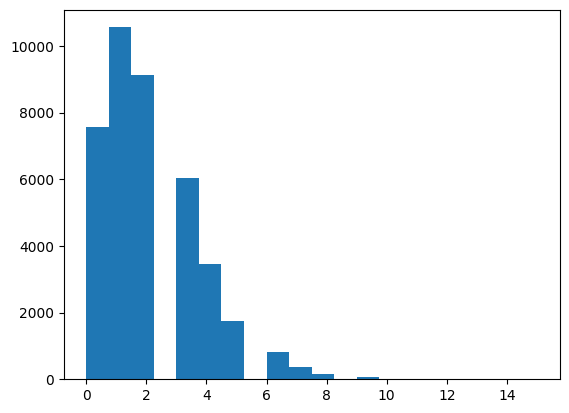

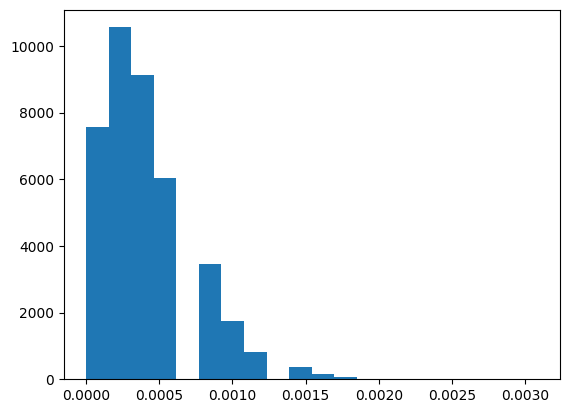

United_States__Kansas
0.000575


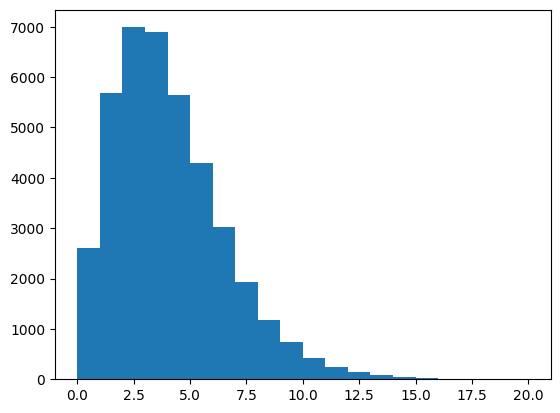

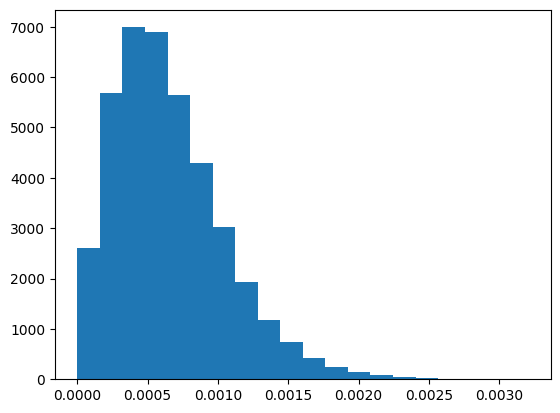

United_States__Kentucky
0.0007166666666666


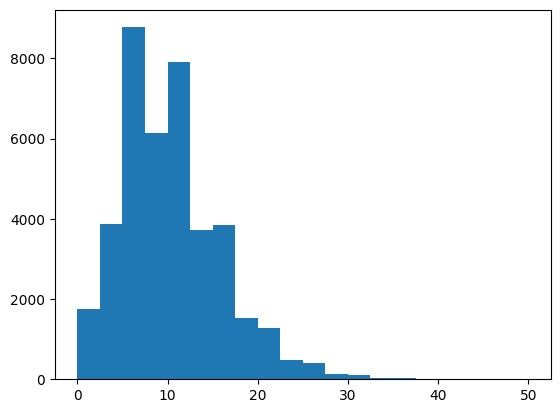

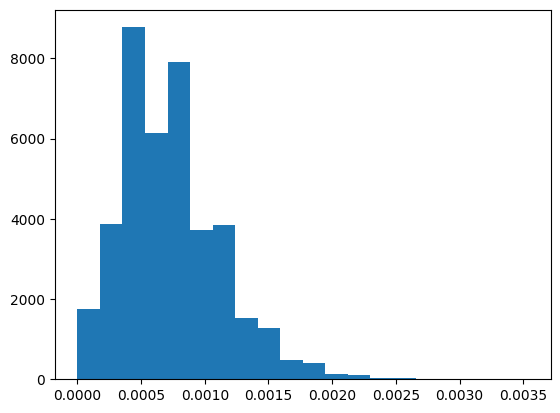

United_States__Louisiana
0.0016583333333333


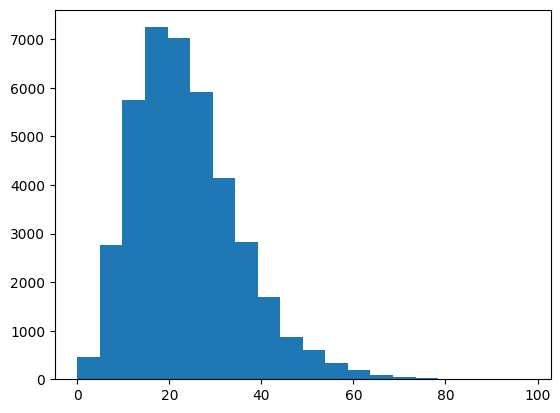

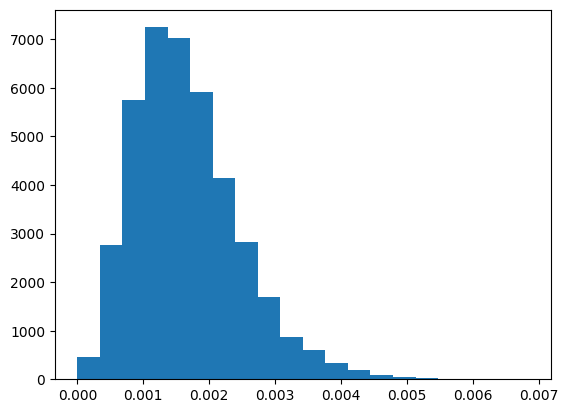

United_States__Maine
0.0005416666666666


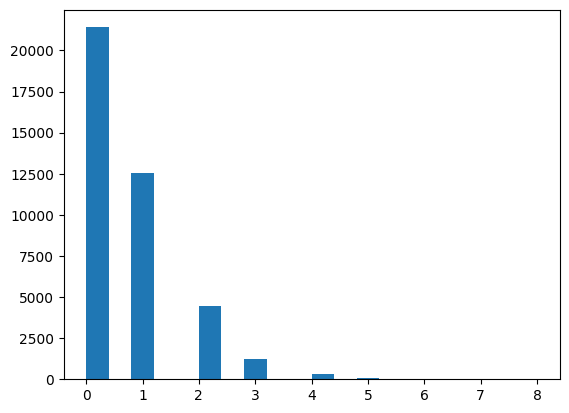

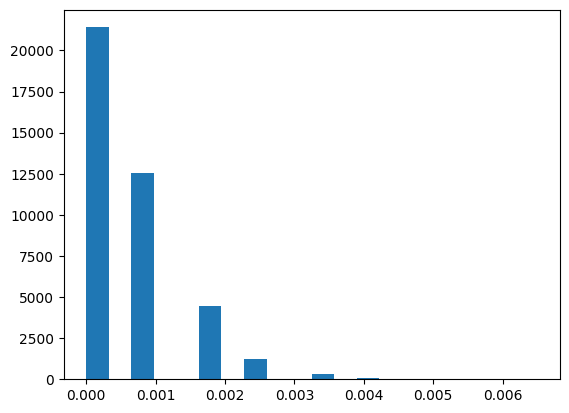

United_States__Maryland
0.0007999999999998999


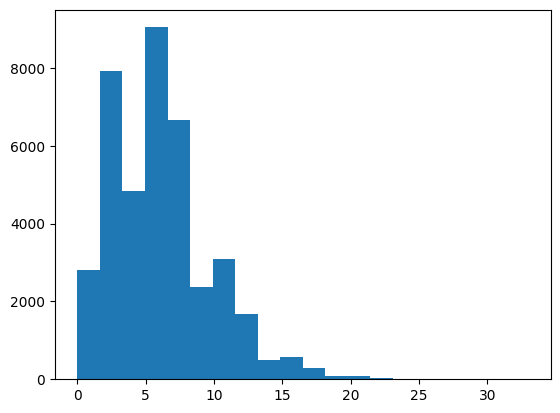

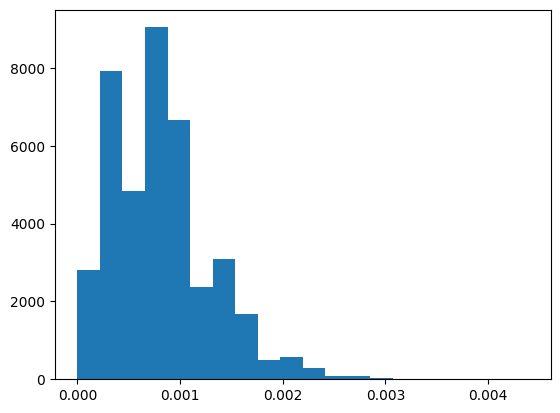

United_States__Massachusetts
0.000575


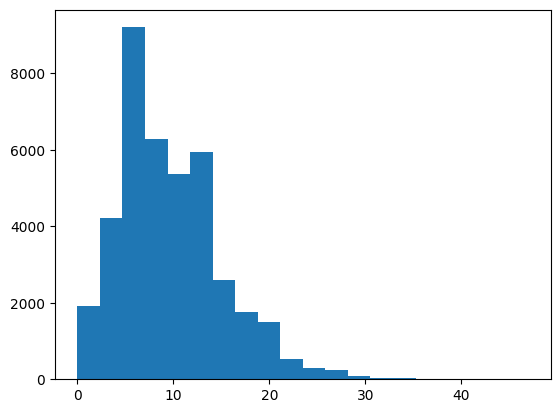

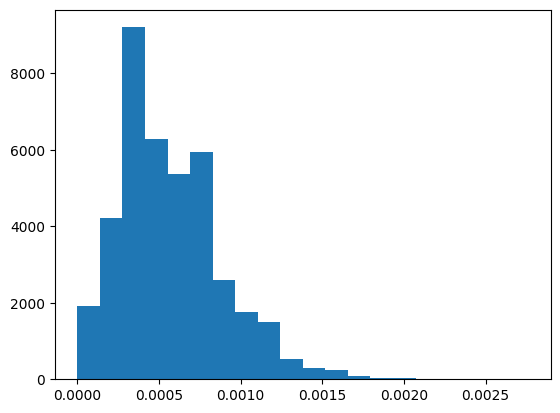

United_States__Michigan
0.00035


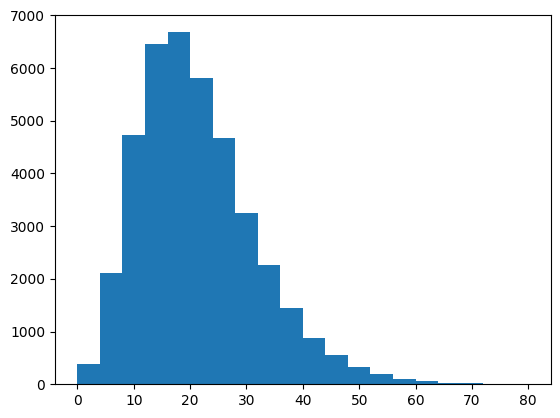

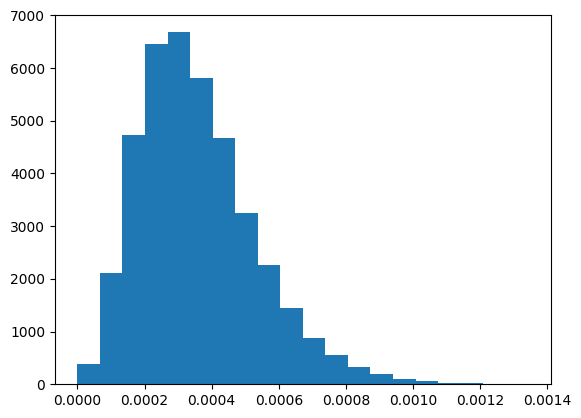

United_States__Minnesota
0.0007916666666666


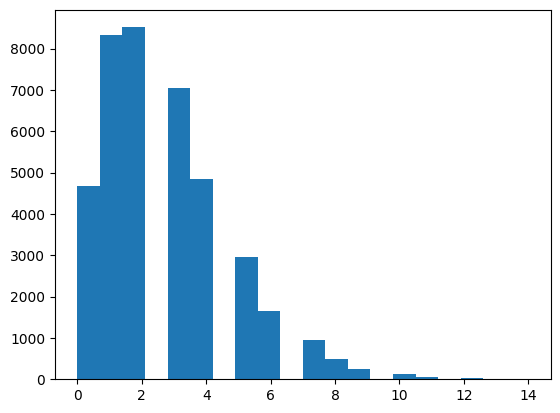

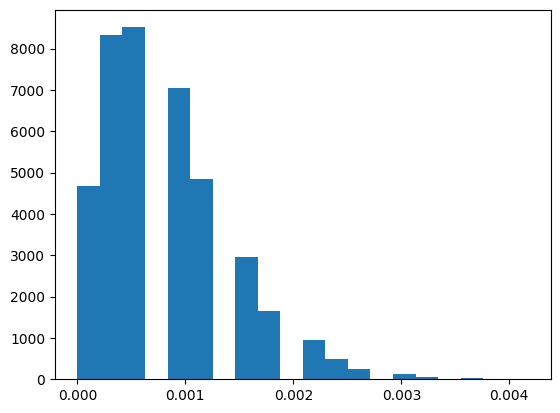

United_States__Mississippi
0.0022083333333333


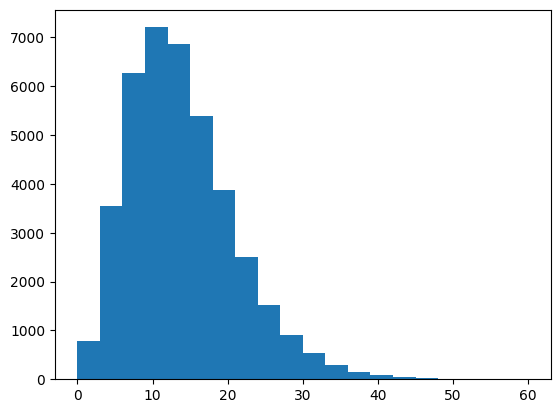

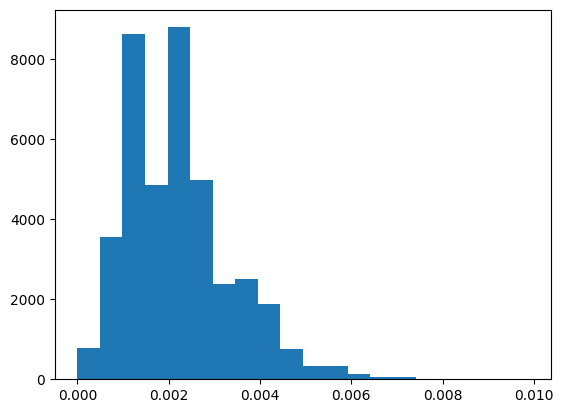

United_States__Missouri


IndexError: index 0 is out of bounds for axis 0 with size 0

In [73]:
random_combined["samples"] = baseline_sample
locations = random_combined["location"].unique()
for loc in locations:
    print(loc)
    df_loc_filtered = random_combined[random_combined["location"] == loc]
    filtered_samples = df_loc_filtered["samples"]
    ed_baseline = baselines_ed_avg[baselines_ed_avg["location_name_epydemix"] == loc]["baseline"].values[0]
    scaling_factor = ed_baseline / np.mean(filtered_samples)

    # print(ed_baseline)
    filtered_samples_ed = filtered_samples * scaling_factor
    print(np.mean(filtered_samples_ed))
    plt.hist(filtered_samples,bins=20)
    plt.show()
    plt.hist(filtered_samples_ed,bins=20)
    plt.show()

In [19]:
random_combined[random_combined.baseline_sample != 0]

,sample_id,sim_id_h1,sim_id_h3,sim_id_b,location,date,target_h1,target_h3,target_b,target_sum,baseline_sample,target_total
0,264,771,371,0,United_States,2025-09-20,NaN,NaN,NaN,0.0,1549,1549.0
1,264,771,371,0,United_States,2025-09-27,NaN,NaN,NaN,0.0,1614,1614.0
2,264,771,371,0,United_States,2025-10-04,NaN,NaN,NaN,0.0,843,843.0
3,264,771,371,0,United_States,2025-10-11,NaN,NaN,NaN,0.0,942,942.0
4,264,771,371,0,United_States,2025-10-18,NaN,NaN,NaN,0.0,800,800.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2079988,529,474,482,999,United_States__Wyoming,2026-04-04,0.0,0.0,7.0,7.0,3,10.0
2079991,529,474,482,999,United_States__Wyoming,2026-04-25,0.0,0.0,2.0,2.0,1,3.0
2079992,529,474,482,999,United_States__Wyoming,2026-05-02,0.0,0.0,2.0,2.0,1,3.0
2079996,529,474,482,999,United_States__Wyoming,2026-05-30,0.0,0.0,1.0,1.0,1,2.0


In [18]:
random_combined.target_sum.median()

np.float64(27.0)

In [8]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (2080, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,257.96,304.825,370.95,461.0,523.85,572.0,613.75,650.0,...,1059.35,1128.3,1216.00,1297.0,1409.15,1552.4,1778.20,2077.225,2465.21,US
1,United_States,2025-09-27,248.90,286.975,362.95,454.0,528.70,594.6,645.00,706.7,...,1189.70,1331.6,1472.75,1619.2,1890.45,2310.5,2796.25,3199.600,3493.12,US
2,United_States,2025-10-04,249.94,346.775,421.80,508.0,585.85,653.8,716.75,780.0,...,1559.65,1829.0,2026.75,2262.4,2601.15,2980.1,3399.30,3738.825,4350.58,US
3,United_States,2025-10-11,267.93,349.975,430.80,559.0,657.70,739.8,845.00,935.7,...,1963.35,2136.1,2355.00,2784.4,3124.40,3535.1,4154.25,4604.775,5369.29,US
4,United_States,2025-10-18,301.96,403.925,480.75,596.7,704.00,797.2,909.50,1030.1,...,2354.35,2567.9,2835.50,3113.2,3499.45,3983.1,4691.40,5493.050,6138.07,US
5,United_States,2025-10-25,297.94,418.825,510.80,622.9,760.40,884.8,1042.00,1235.0,...,2693.40,2967.3,3190.00,3563.2,3944.35,4561.0,5516.40,6108.425,6881.07,US
6,United_States,2025-11-01,324.00,454.975,569.65,758.8,961.25,1157.2,1369.25,1596.0,...,3026.45,3336.6,3616.75,3899.6,4432.20,5116.4,6188.75,6791.675,7471.13,US
7,United_States,2025-11-08,354.87,533.700,709.00,1075.7,1379.25,1662.8,1961.00,2167.1,...,3786.05,4043.0,4402.25,4749.8,5267.80,5925.5,7464.40,8267.000,9354.29,US
8,United_States,2025-11-15,552.00,711.625,1006.30,1626.7,1948.90,2254.6,2504.25,2755.6,...,4540.70,4838.5,5221.25,5616.8,6200.05,7063.7,8491.90,9805.750,10705.31,US
9,United_States,2025-11-22,821.53,1220.250,1686.55,2270.0,2778.95,3129.0,3377.00,3693.5,...,5749.35,6131.2,6491.75,7046.4,7657.30,8618.5,10418.85,12117.200,13274.58,US


## Plot

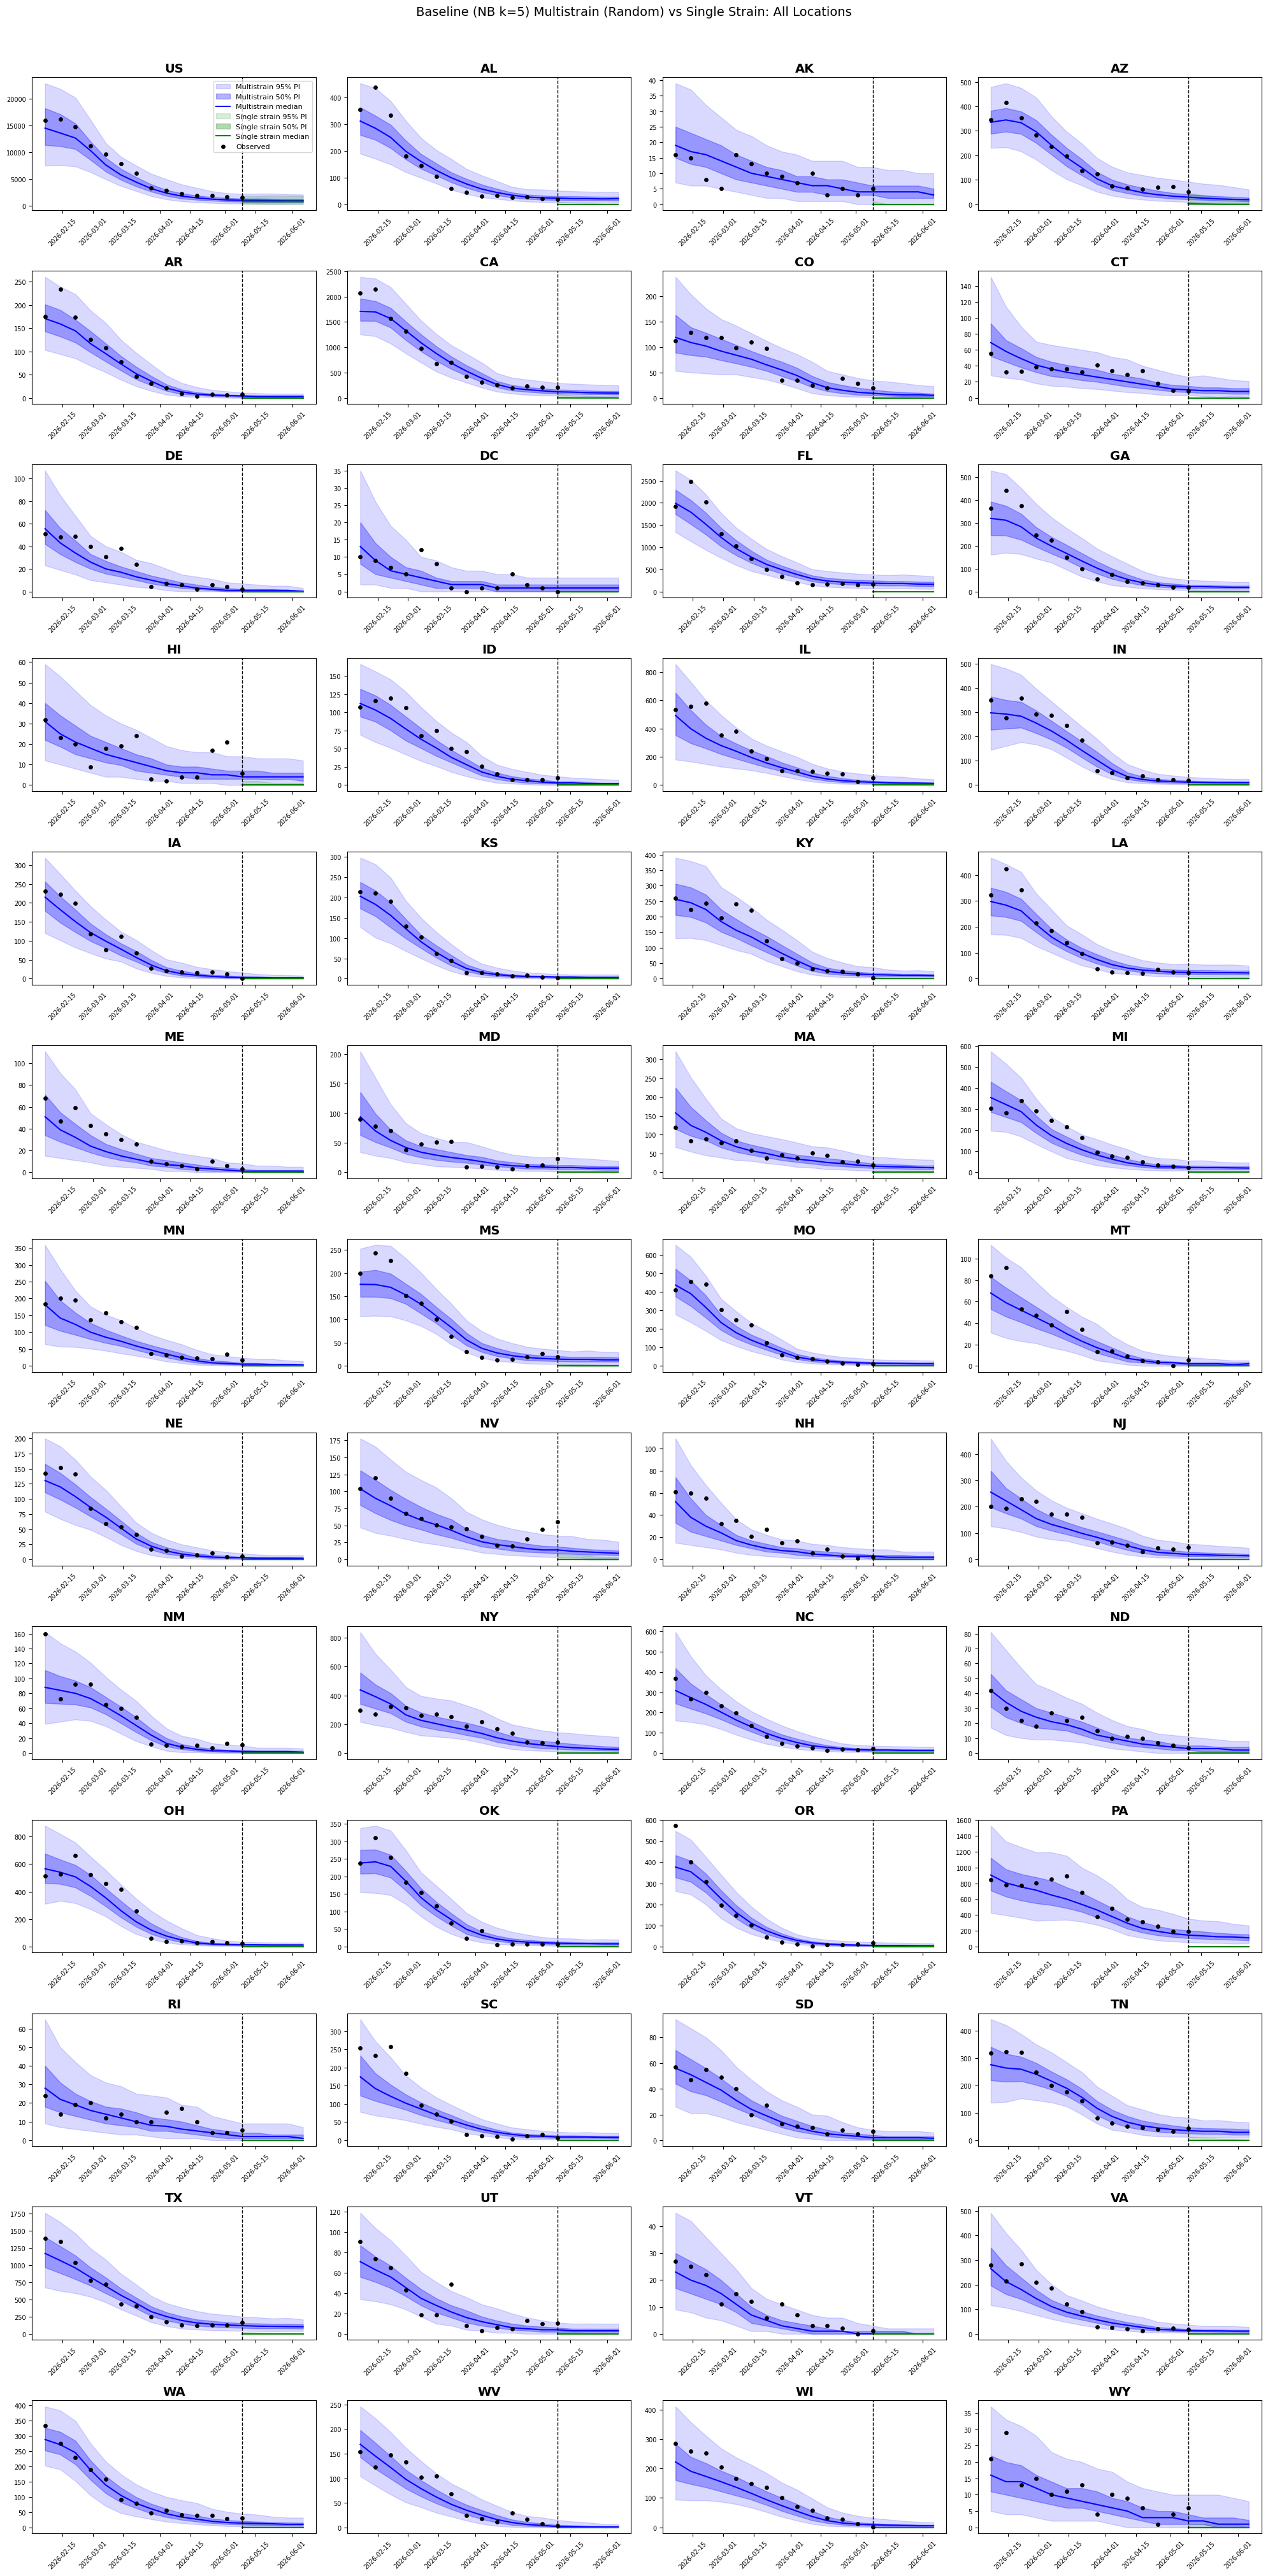

In [17]:
FILTER_PLOT = True
FILTER_PLOT_START = '2026-02-01'
LONG_PLOT_START = '2025-10-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    fname_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    fname_prefix = ''

if BASELINE:
    plot_title = f'Baseline (NB k={BASELINE_k}) Multistrain (Random) vs Single Strain: All Locations'
    fname_prefix += 'baseline_'
else:
    plot_title = 'Multistrain (Random) vs Single Strain: All Locations'

plot_fname = f"{fname_prefix}{MULTISTRAIN_EXPERIMENT}_multistrain_vs_single_comparison.pdf"

# Filter data
random_quantiles_filter = random_quantiles[
    (random_quantiles['date'] >= plot_start_date) &
    (random_quantiles['date'] < final_date)
]
fit_surv_data_filter = fit_surv_data[
    (fit_surv_data['date'] >= plot_start_date) &
    (fit_surv_data['date'] < final_date)
]

if INCLUDE_SINGLE_STRAIN:
    # Convert df_single to wide format for plotting (matching random_quantiles format)
    df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
    df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])
    
    # Pivot to get quantile columns
    df_single_wide = df_single_quantiles.pivot_table(
        index=['location', 'target_end_date'],
        columns='output_type_id',
        values='value'
    ).reset_index()
    
    # Rename columns to match random_quantiles format
    df_single_wide.columns.name = None
    df_single_wide = df_single_wide.rename(columns={
        'target_end_date': 'date',
        '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
    })
    
    # Filter to date range
    df_single_filter = df_single_wide[
        (df_single_wide['date'] >= plot_start_date) & 
        (df_single_wide['date'] < final_date)
    ]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = convert_location_name_format(
        value=pop,
        output_format="abbreviation",
        location_type="iso"
    )
    location_code = convert_location_name_format(
        value=abbrev,
        output_format="FIPS",
        input_format="abbreviation",
        location_type="iso"
    )
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    hosp_pop = fit_surv_data_filter[fit_surv_data_filter['abbreviation'] == abbrev].sort_values('date')
    if INCLUDE_SINGLE_STRAIN:
        single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    if INCLUDE_SINGLE_STRAIN:
        ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                        alpha=0.15, color='green', label='Single strain 95% PI')
        ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                        alpha=0.3, color='green', label='Single strain 50% PI')
        ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(hosp_pop['date'], hosp_pop['hospitalizations'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)
    
plt.suptitle(plot_title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/{plot_fname}', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [10]:
# Compute rate trend categories for each trajectory
# Baseline comes from surveillance data, target from trajectories
categories_df = compute_rate_trend_categories(
    df=random_combined,
    reference_date=REFERENCE_DATE,
    surveillance_df=fit_surv_data,
    horizons=get_flusight_categorical_horizons(),
    value_col=VALUE_COL,
    surveillance_date_col='date',
    surveillance_value_col='hospitalizations',
    surveillance_location_col='abbreviation'
)

print(f"Categories computed: {len(categories_df):,} rows")
print(f"Unique populations: {categories_df['population'].nunique()}")
print(f"Horizons: {sorted(categories_df['horizon'].unique())}")
print(f"\nCategory distribution:")
print(categories_df['category'].value_counts())
print(f"\nBaseline values come from surveillance (same for all samples per location):")
categories_df.tail(10)

Categories computed: 208,000 rows
Unique populations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Category distribution:
category
stable            195668
decrease           10143
increase            2180
large_increase         8
large_decrease         1
Name: count, dtype: int64

Baseline values come from surveillance (same for all samples per location):


,reference_date,sample_id,population,abbreviation,baseline_date,horizon,target_date,baseline_value,target_value,count_change,rate_change,category
207990,2026-05-16,240,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,1.0,-4.909246,-0.835449,stable
207991,2026-05-16,221,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,1.0,-4.909246,-0.835449,stable
207992,2026-05-16,961,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,0.0,-5.909246,-1.005627,stable
207993,2026-05-16,339,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,1.0,-4.909246,-0.835449,stable
207994,2026-05-16,419,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,0.0,-5.909246,-1.005627,stable
207995,2026-05-16,847,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,1.0,-4.909246,-0.835449,stable
207996,2026-05-16,179,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,0.0,-5.909246,-1.005627,stable
207997,2026-05-16,465,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,0.0,-5.909246,-1.005627,stable
207998,2026-05-16,516,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,5.0,-0.909246,-0.154734,stable
207999,2026-05-16,529,United_States__Wyoming,WY,2026-05-09,3,2026-06-06,5.909246,1.0,-4.909246,-0.835449,stable


In [11]:
# Compute PMF from categories
pmf_df = compute_rate_trend_pmf(categories_df)

print(f"PMF shape: {pmf_df.shape}")
print(f"Columns: {pmf_df.columns.tolist()}")
print(f"\nProbabilities sum to 1: {(pmf_df[RATE_TREND_CATEGORIES].sum(axis=1).round(6) == 1).all()}")

PMF shape: (208, 9)
Columns: ['population', 'abbreviation', 'horizon', 'target_date', 'large_decrease', 'decrease', 'stable', 'increase', 'large_increase']

Probabilities sum to 1: True


In [12]:
# Format PMF for hub submission (long format)
pmf_long = pmf_df.melt(
    id_vars=['population', 'abbreviation', 'horizon', 'target_date'],
    value_vars=RATE_TREND_CATEGORIES,
    var_name='output_type_id',
    value_name='value'
)

# Add required columns for FluSight format
pmf_long['target'] = 'wk flu hosp rate change'
pmf_long['output_type'] = 'pmf'
pmf_long['location'] = pmf_long['abbreviation']

# Reorder columns
hub_pmf = pmf_long[[
    'location', 'target', 'horizon', 'target_date', 
    'output_type', 'output_type_id', 'value'
]]

print(f"Hub submission format shape: {hub_pmf.shape}")
print(f"\nSample rows:")
hub_pmf.head(15)

Hub submission format shape: (1040, 7)

Sample rows:


,location,target,horizon,target_date,output_type,output_type_id,value
0,US,wk flu hosp rate change,0,2026-05-16,pmf,large_decrease,0.0
1,US,wk flu hosp rate change,1,2026-05-23,pmf,large_decrease,0.0
2,US,wk flu hosp rate change,2,2026-05-30,pmf,large_decrease,0.0
3,US,wk flu hosp rate change,3,2026-06-06,pmf,large_decrease,0.0
4,AL,wk flu hosp rate change,0,2026-05-16,pmf,large_decrease,0.0
5,AL,wk flu hosp rate change,1,2026-05-23,pmf,large_decrease,0.0
6,AL,wk flu hosp rate change,2,2026-05-30,pmf,large_decrease,0.0
7,AL,wk flu hosp rate change,3,2026-06-06,pmf,large_decrease,0.0
8,AK,wk flu hosp rate change,0,2026-05-16,pmf,large_decrease,0.0
9,AK,wk flu hosp rate change,1,2026-05-23,pmf,large_decrease,0.0


In [13]:
# Export PMF for hub submission (uncomment to save)
# output_file = f"../data/multistrain-data/{SUBMISSION_WEEK}/rate_trend_pmf.csv"
# hub_pmf.to_csv(output_file, index=False)
# print(f"Saved PMF to: {output_file}")

# Verify probabilities sum to 1 for each location/horizon
verification = hub_pmf.groupby(['location', 'horizon'])['value'].sum()
print("All PMFs sum to 1:", (verification.round(6) == 1).all())
print(f"\nTotal PMF entries: {len(hub_pmf)}")
print(f"Locations: {hub_pmf['location'].nunique()}")
print(f"Horizons: {sorted(hub_pmf['horizon'].unique())}")
print(f"Categories per location/horizon: {len(RATE_TREND_CATEGORIES)}")

All PMFs sum to 1: True

Total PMF entries: 1040
Locations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Categories per location/horizon: 5


In [14]:
# Create complete FluSight submission
submission = create_flusight_submission(
    trajectories_df=random_combined,
    pmf_df=pmf_df,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),
    value_col=VALUE_COL
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (7020, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk flu hosp rate change', 'wk inc flu hosp']
Length: 2, dtype: str
Output types: <StringArray>
['pmf', 'quantile']
Length: 2, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 52

Rows per target:
target                   output_type
wk flu hosp rate change  pmf            1040
wk inc flu hosp          quantile       5980
dtype: int64


In [15]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-16,0,2026-05-16,01,wk flu hosp rate change,pmf,decrease,0.004
1,2026-05-16,0,2026-05-16,01,wk flu hosp rate change,pmf,increase,0.153
2,2026-05-16,0,2026-05-16,01,wk flu hosp rate change,pmf,large_decrease,0.000
3,2026-05-16,0,2026-05-16,01,wk flu hosp rate change,pmf,large_increase,0.000
4,2026-05-16,0,2026-05-16,01,wk flu hosp rate change,pmf,stable,0.843
...,...,...,...,...,...,...,...,...
7015,2026-05-16,3,2026-06-06,US,wk inc flu hosp,quantile,0.85,1404.000
7016,2026-05-16,3,2026-06-06,US,wk inc flu hosp,quantile,0.9,1557.000
7017,2026-05-16,3,2026-06-06,US,wk inc flu hosp,quantile,0.95,1821.000
7018,2026-05-16,3,2026-06-06,US,wk inc flu hosp,quantile,0.975,2071.000


In [16]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"{WORKING_DIR}/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)